# Notebook 05 — Análise dos Resultados
## Pipeline 1 — Mallows + Plackett–Luce | Projeto Fórmula 1 — TCC

### Estrutura do notebook
1. Configuração e carregamento dos resultados
2. Métricas de avaliação — Top-3, Top-5 e Kendall Tau
3. Skill Scores — o que são e como evoluíram
4. Clusters do Mallows — padrões de corrida descobertos
5. Pesos regulatórios — impacto da mudança de regulamento
6. Skill Scores por Cluster
7. Conclusões

---

### Contexto do experimento

| Split | Temporadas | Corridas | Função |
|---|---|---|---|
| **Treino** | 2019–2022 | 82 | Aprendizado inicial dos padrões |
| **Validação** | 2023 | 22 | Calibração e avaliação intermediária |
| **Teste** | 2024 | 24 | Avaliação final — dados nunca vistos |


## 1. Configuração

In [12]:
import sys, os, pickle
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

# Paths do projeto
PROJECT_ROOT = r'C:/Users/guiga/OneDrive/Documentos/Projeto-Formula1'
PIPELINE1_DIR = os.path.join(PROJECT_ROOT, 'src', 'pipeline_mallows_plackett_luce')
SRC_DIR = os.path.join(PROJECT_ROOT, 'src')

sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, PIPELINE1_DIR)

from src.pipeline_mallows_plackett_luce.visualization_plots import (
    plot_skill_evolution, plot_cluster_map,
    plot_regulatory_weights, plot_skill_ranking,
    SkillSnapshot, TEAM_COLORS, CLUSTER_COLORS,
)
from src.evaluation.evaluation_metrics  import season_summary
from src.models.models_plackett_luce    import ranked_drivers

# Carregar dados gerados pelo run_experiment.py
output_file = os.path.join(PIPELINE1_DIR, 'outputs', 'nb_data.pkl')
with open(output_file, 'rb') as f:
    data = pickle.load(f)

state         = data['state']
val_evals     = data['val_evals']
test_evals    = data['test_evals']
all_snapshots = data['all_snapshots']
train_records = data['train_records']
train_seasons = data['train_seasons']
train_races   = data['train_races']
weights_arr   = data['weights_arr']
all_drivers   = data['all_drivers']

val_summary  = season_summary(val_evals,  2023)
test_summary = season_summary(test_evals, 2024)

print("Dados carregados com sucesso.")
print(f"  Snapshots de skill score: {len(all_snapshots)}")
print(f"  Avaliações — validação:   {len(val_evals)} corridas")
print(f"  Avaliações — teste:       {len(test_evals)} corridas")


Dados carregados com sucesso.
  Snapshots de skill score: 46
  Avaliações — validação:   22 corridas
  Avaliações — teste:       24 corridas


## 2. Métricas de Avaliação

### O que cada métrica significa

**Top-3 Accuracy** — De cada 3 pilotos previstos no pódio, quantos
realmente chegaram no pódio? Um valor de 0.667 significa que 2 dos 3
previstos estavam certos.

**Top-5 Accuracy** — Mesma lógica, mas considerando os 5 primeiros.
Naturalmente mais alto que o Top-3 por ter mais margem de acerto.

**Kendall Tau (τ)** — Mede se o modelo acertou a *ordem relativa* entre
os pilotos. Varia de -1 (ordem completamente invertida) a +1 (ordem perfeita).
Um valor de 0.422 significa que o modelo acertou a ordem de aproximadamente
70% dos pares de pilotos — calculado como (1 + τ) / 2.


In [13]:
print("VALIDAÇÃO 2023")
print(f"{'Corrida':22s} {'Cluster':>8} {'Top-3':>8} {'Top-5':>8} {'Kendall τ':>10}")
print("-" * 60)
for e in val_evals:
    print(f"{e.race:22s} {e.cluster_used+1:>8d} {e.top3_acc:>8.3f} "
          f"{e.top5_acc:>8.3f} {e.kendall_tau:>10.3f}")
print("-" * 60)
print(f"{'MÉDIA':22s} {'':>8} {val_summary.mean_top3:>8.3f} "
      f"{val_summary.mean_top5:>8.3f} {val_summary.mean_kendall:>10.3f}")


VALIDAÇÃO 2023
Corrida                 Cluster    Top-3    Top-5  Kendall τ
------------------------------------------------------------
Bahrain                       2    0.333    0.800      0.410
Saudi Arabia                  1    0.667    0.800      0.606
Australia                     1    0.667    0.600      0.333
Azerbaijan                    1    0.667    0.600      0.485
Miami                         1    0.667    0.600      0.556
Monaco                        2    0.333    0.400      0.345
Spain                         1    0.667    0.800      0.778
Canada                        1    0.667    0.600      0.455
Austria                       1    0.667    0.600      0.382
Great Britain                 2    0.667    0.400      0.242
Hungary                       2    0.333    0.600      0.455
Belgium                       1    0.667    0.800      0.667
Netherlands                   1    0.333    0.400      0.462
Italy                         1    0.667    0.800      0.606
Singapore

In [14]:
print("TESTE 2024")
print(f"{'Corrida':22s} {'Cluster':>8} {'Top-3':>8} {'Top-5':>8} {'Kendall τ':>10}")
print("-" * 60)
for e in test_evals:
    print(f"{e.race:22s} {e.cluster_used+1:>8d} {e.top3_acc:>8.3f} "
          f"{e.top5_acc:>8.3f} {e.kendall_tau:>10.3f}")
print("-" * 60)
print(f"{'MÉDIA':22s} {'':>8} {test_summary.mean_top3:>8.3f} "
      f"{test_summary.mean_top5:>8.3f} {test_summary.mean_kendall:>10.3f}")


TESTE 2024
Corrida                 Cluster    Top-3    Top-5  Kendall τ
------------------------------------------------------------
Bahrain                       2    0.667    0.600      0.422
Saudi Arabia                  2    0.667    0.600      0.364
Australia                     2    0.000    0.200     -0.061
Japan                         1    0.333    0.600      0.487
China                         2    0.667    0.400      0.436
Miami                         1    0.667    0.600      0.527
Emilia Romagna                2    0.333    0.200      0.345
Monaco                        1    0.333    0.400      0.341
Canada                        1    0.667    0.800      0.371
Spain                         1    0.667    0.800      0.689
Austria                       2    0.000    0.600      0.200
Great Britain                 2    0.667    0.400      0.364
Hungary                       1    0.333    0.800      0.527
Belgium                       2    0.333    0.600      0.394
Netherlands  

In [15]:
print("RESUMO COMPARATIVO")
print(f"{'Split':20s} {'Top-3':>8} {'Top-5':>8} {'Kendall τ':>10} {'Corridas':>10}")
print("-" * 58)
print(f"{'Validação 2023':20s} {val_summary.mean_top3:>8.3f} "
      f"{val_summary.mean_top5:>8.3f} {val_summary.mean_kendall:>10.3f} "
      f"{val_summary.n_races:>10}")
print(f"{'Teste 2024':20s} {test_summary.mean_top3:>8.3f} "
      f"{test_summary.mean_top5:>8.3f} {test_summary.mean_kendall:>10.3f} "
      f"{test_summary.n_races:>10}")


RESUMO COMPARATIVO
Split                   Top-3    Top-5  Kendall τ   Corridas
----------------------------------------------------------
Validação 2023          0.515    0.618      0.422         22
Teste 2024              0.500    0.583      0.408         24


### Interpretação dos resultados

Os valores de validação (2023) e teste (2024) ficaram muito próximos:
- **Top-3**: 0.515 vs 0.500 — diferença de apenas 1.5 pontos percentuais
- **Top-5**: 0.618 vs 0.583 — diferença de 3.5 pontos percentuais
- **Kendall τ**: 0.422 vs 0.408 — praticamente idênticos

Essa proximidade indica que o modelo **generaliza bem** — aprende padrões reais
e não simplesmente memoriza o histórico.

**Por que 2024 ficou ligeiramente abaixo de 2023?**
Em 2023, Verstappen foi absolutamente dominante (19 vitórias em 22 corridas),
facilitando a previsão. Em 2024, a McLaren emergiu progressivamente, criando
um cenário muito mais competitivo e imprevisível.


### Visualização das métricas ao longo das corridas

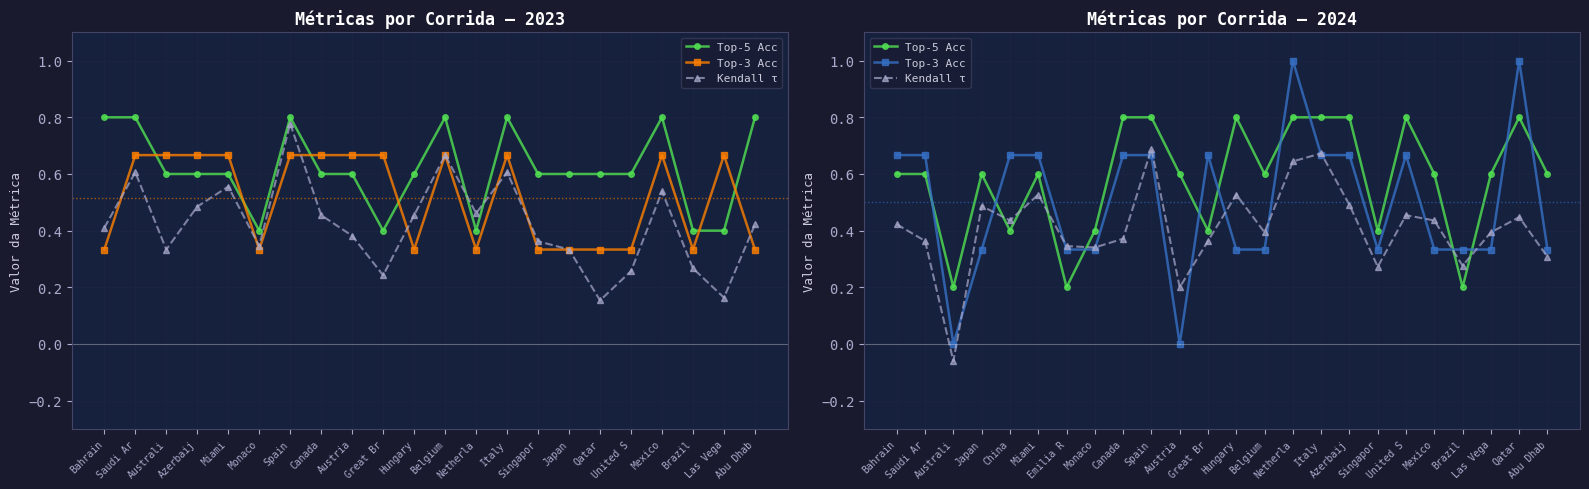

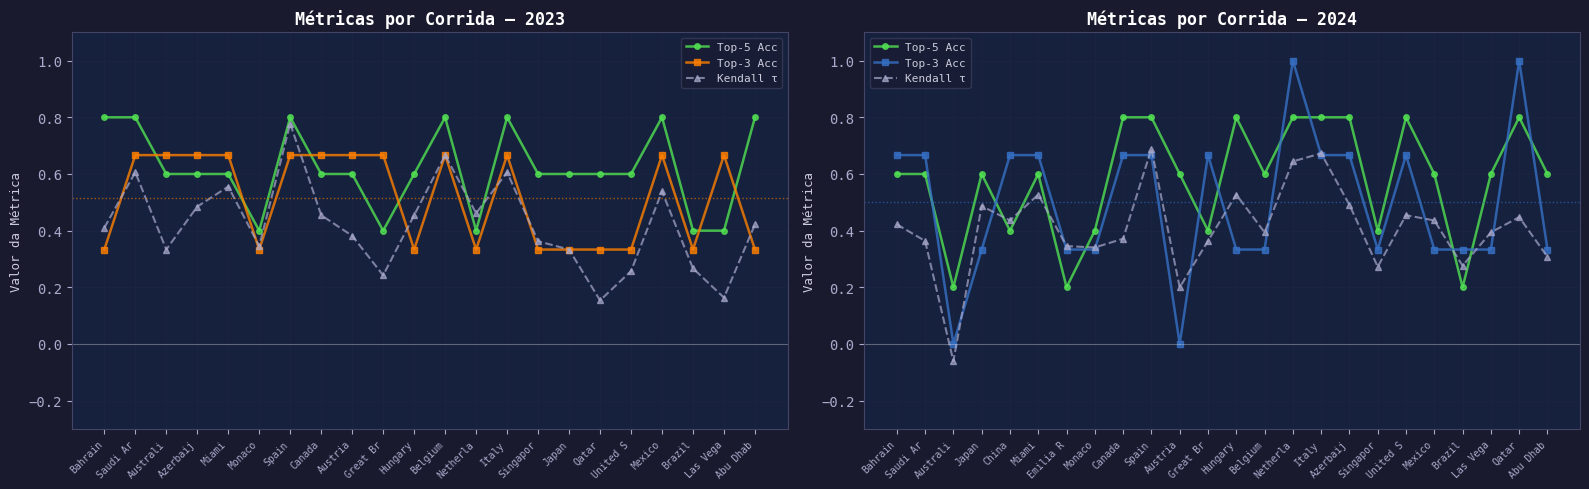

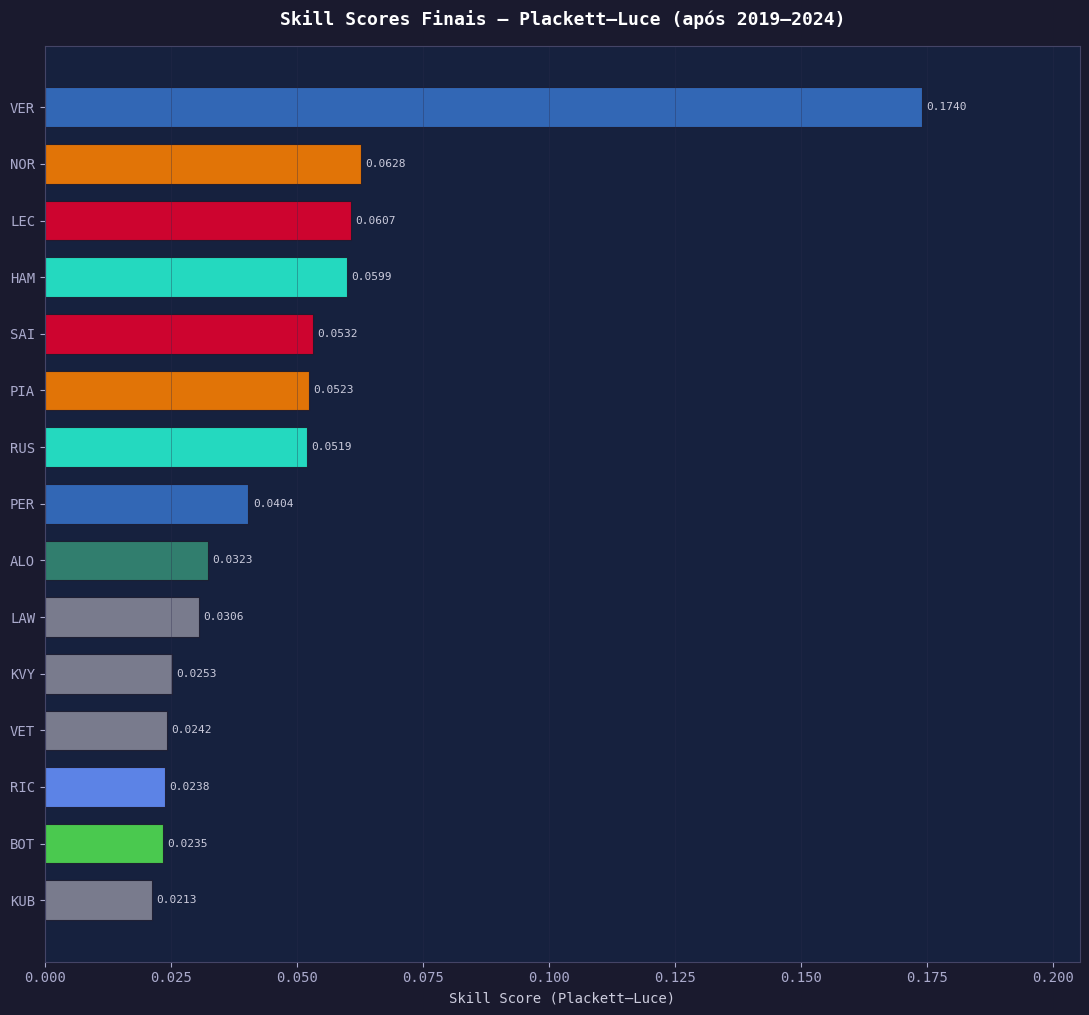

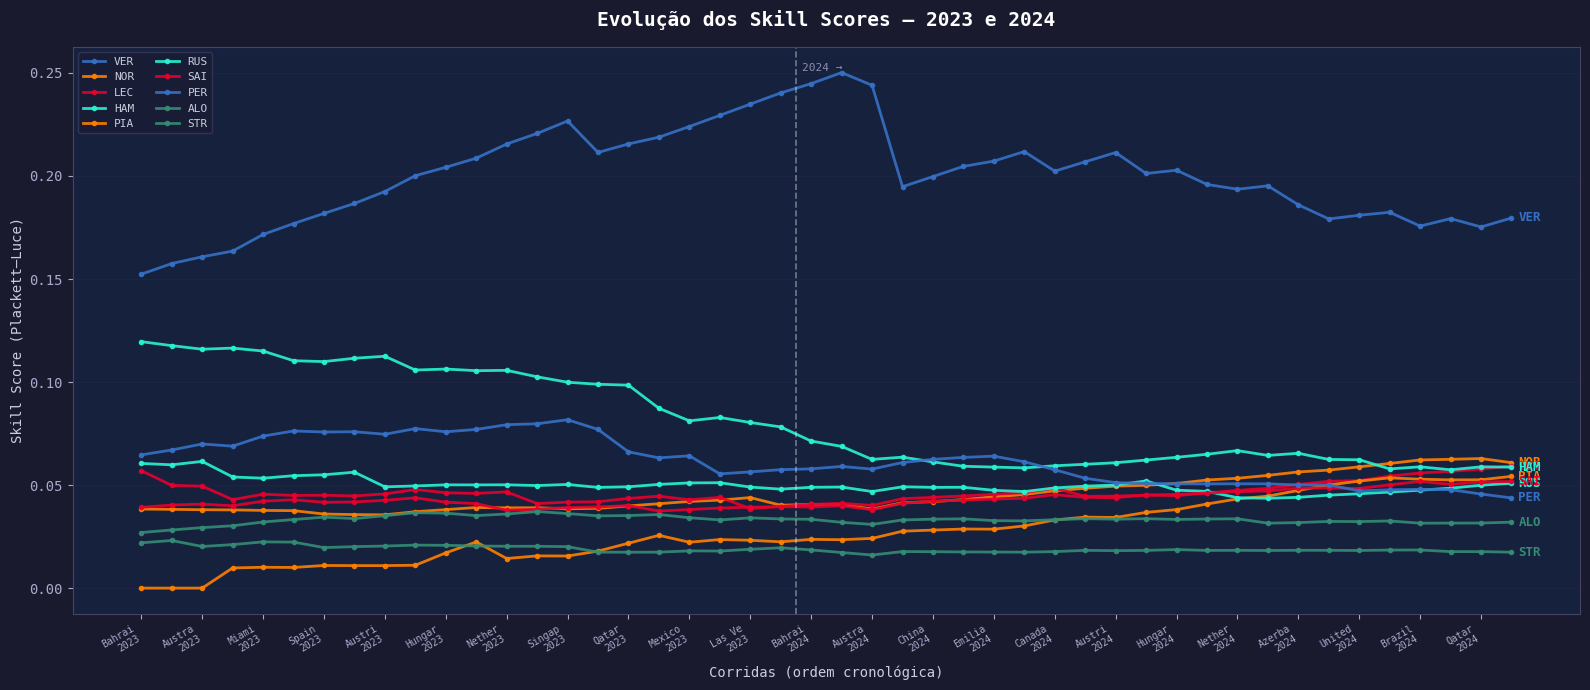

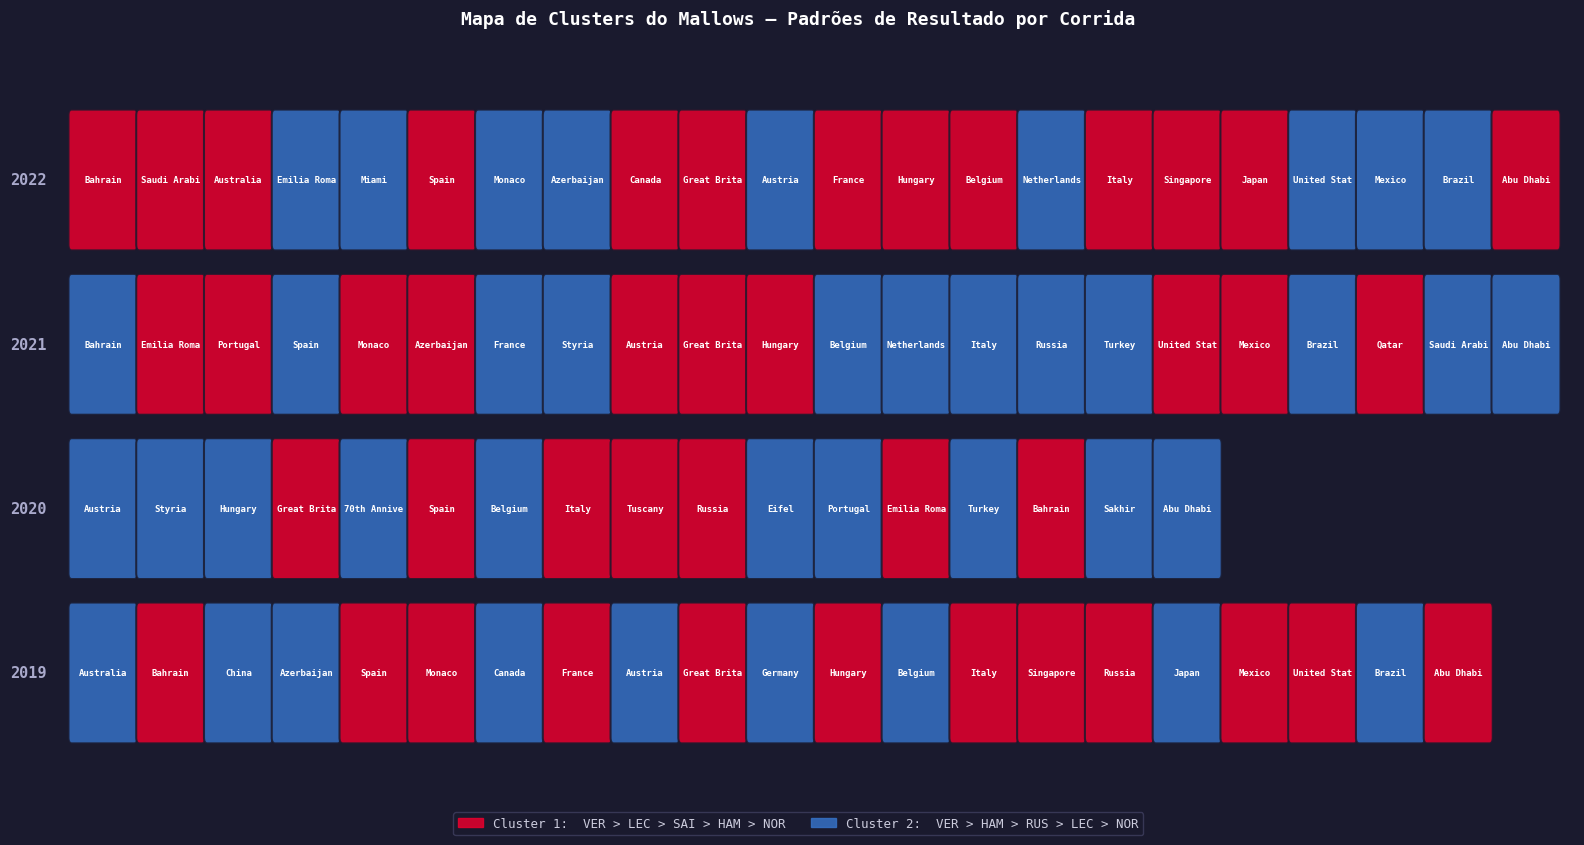

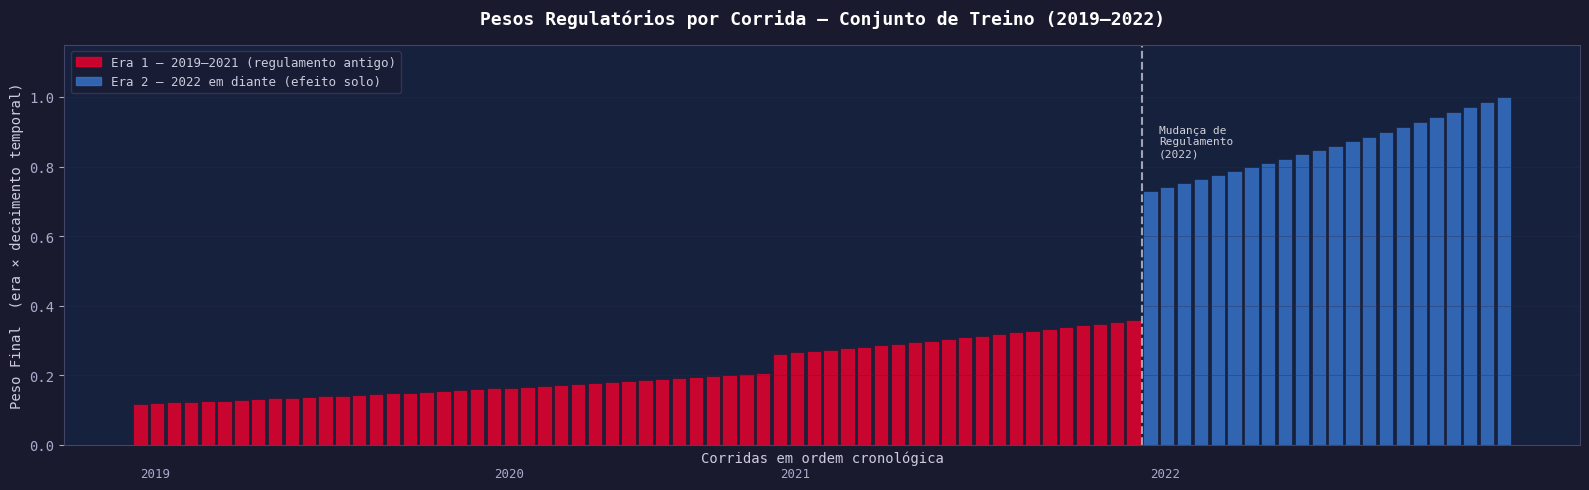

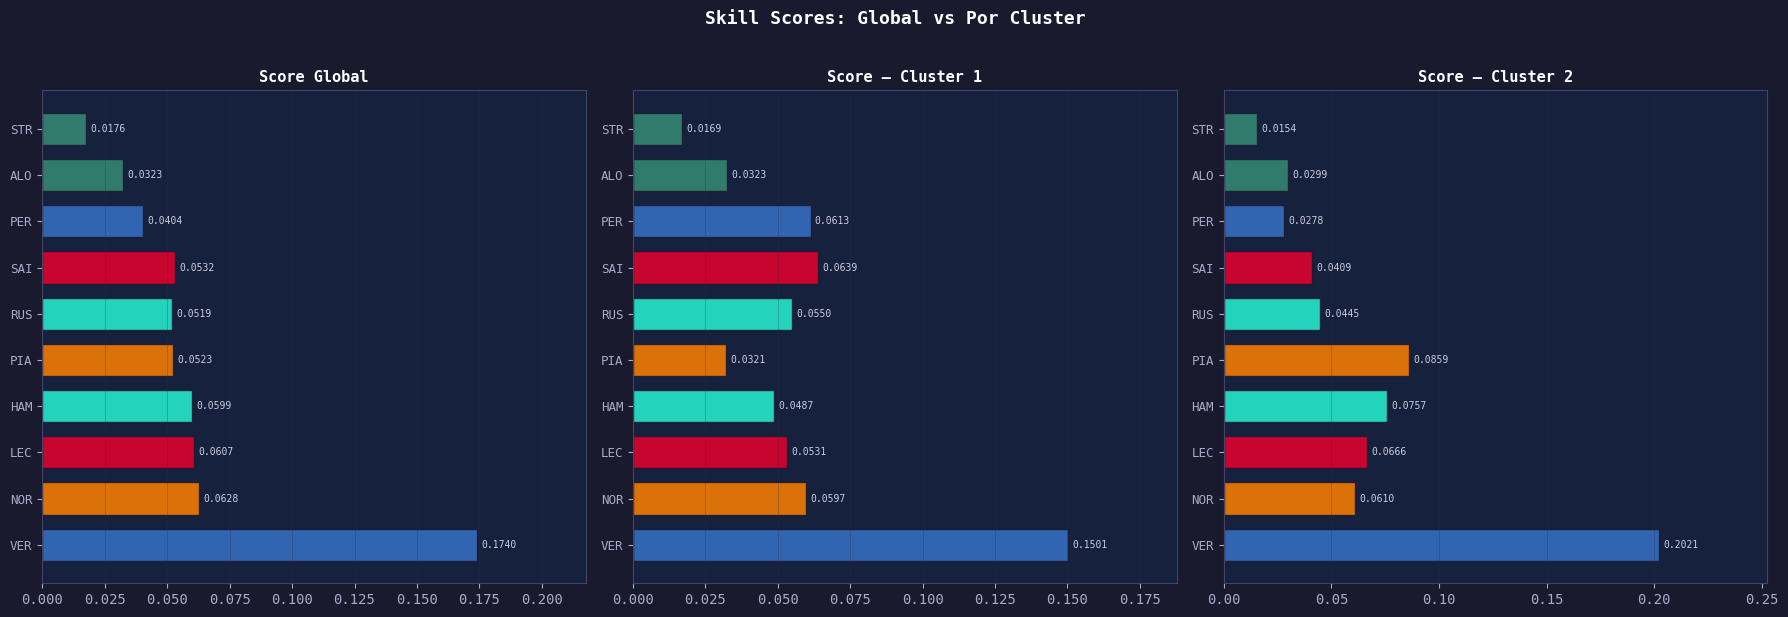

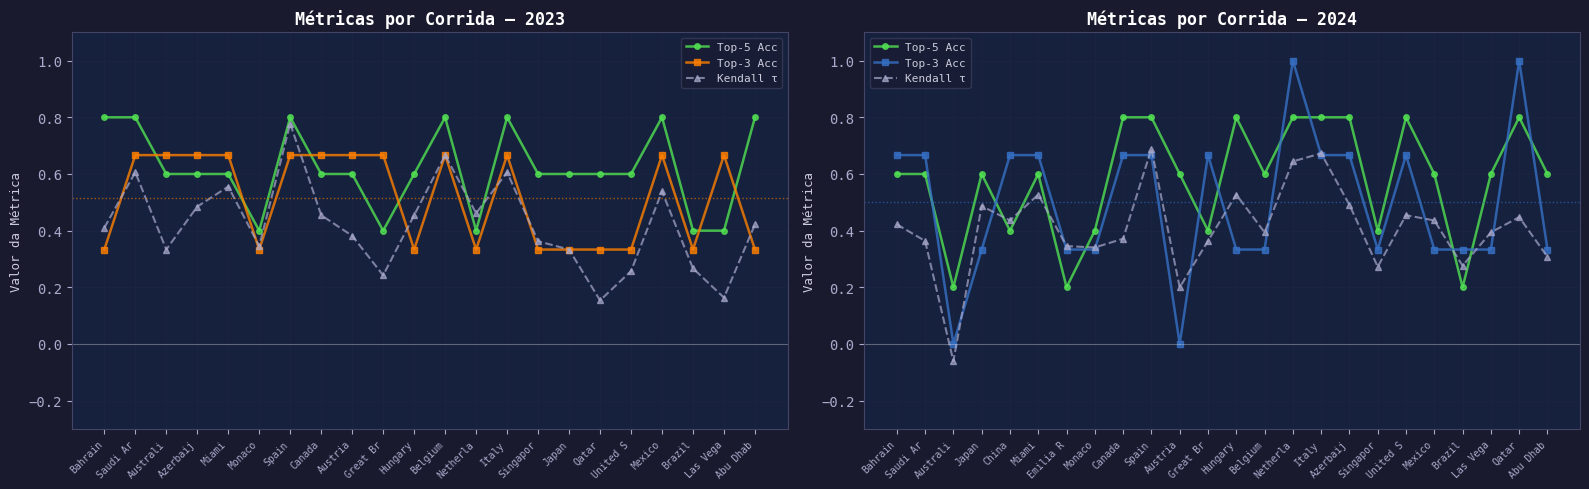

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1a1a2e')

for ax, evals, season, color in zip(
    axes, [val_evals, test_evals], [2023, 2024], ['#FF8000', '#3671C6']
):
    races = [e.race[:8] for e in evals]
    top3  = [e.top3_acc    for e in evals]
    top5  = [e.top5_acc    for e in evals]
    ktau  = [e.kendall_tau for e in evals]
    x     = range(len(races))

    ax.plot(x, top5, color='#52E252', linewidth=1.8, label='Top-5 Acc',
            marker='o', markersize=4, alpha=0.8)
    ax.plot(x, top3, color=color,     linewidth=1.8, label='Top-3 Acc',
            marker='s', markersize=4, alpha=0.8)
    ax.plot(x, ktau, color='#aaaacc', linewidth=1.5, label='Kendall τ',
            marker='^', markersize=4, linestyle='--', alpha=0.7)

    ax.axhline(y=0, color='#ffffff', linewidth=0.8, alpha=0.3)
    ax.axhline(y=np.mean(top3), color=color, linewidth=1.0,
               linestyle=':', alpha=0.6)
    ax.set_xticks(list(x))
    ax.set_xticklabels(races, rotation=45, ha='right', fontsize=7)
    ax.set_title(f'Métricas por Corrida — {season}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor da Métrica', fontsize=9)
    ax.set_ylim(-0.3, 1.1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, framealpha=0.6)

plt.tight_layout()
display(fig)


## 3. Skill Scores — Plackett–Luce

### O que são os skill scores

O modelo Plackett–Luce associa a cada piloto um parâmetro de habilidade
λ_i que representa sua **força relativa** de superar outros pilotos em
qualquer corrida. O algoritmo MM estima esses parâmetros olhando para todos
os duelos posicionais ponderados pelo peso regulatório de cada corrida.


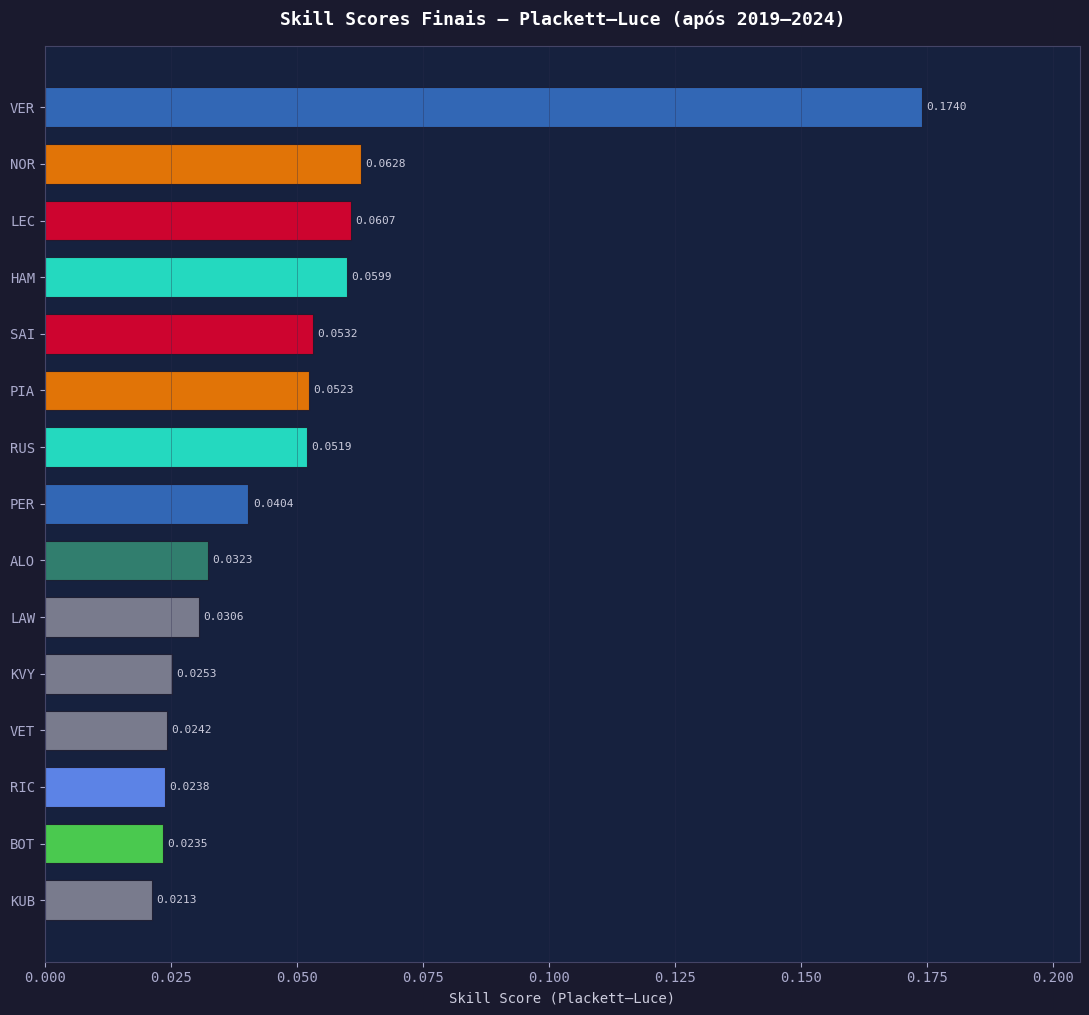

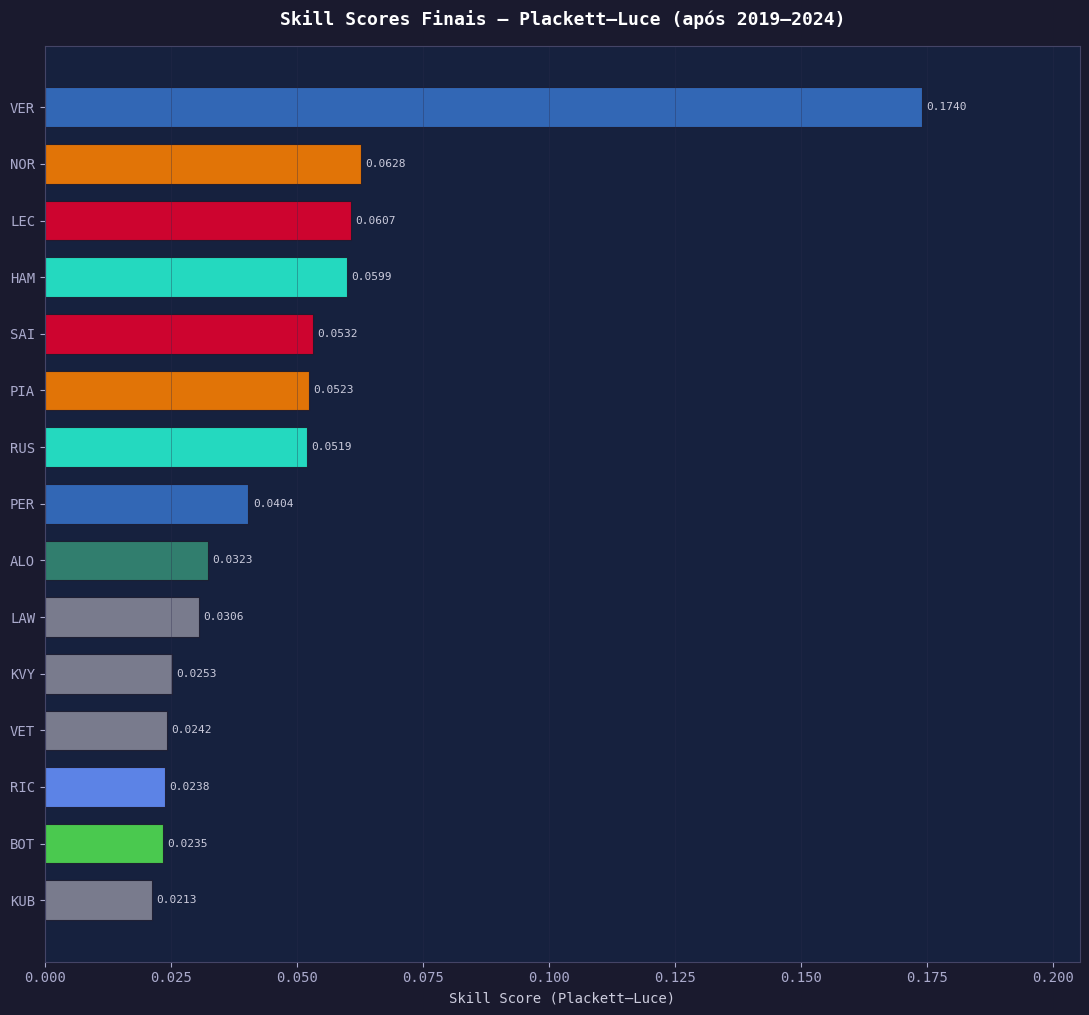

In [17]:
fig = plot_skill_ranking(
    skill_scores = state.pl.global_scores,
    top_n        = 15,
    title        = 'Skill Scores Finais — Plackett–Luce (após 2019–2024)',
)
plt.tight_layout()
display(fig)


### Interpretação dos skill scores finais

| Piloto | Score | Interpretação |
|---|---|---|
| **VER** | ~0.174 | Domínio absoluto em 2021–2023 com pesos regulatórios altos |
| **NOR** | ~0.063 | Crescimento expressivo em 2024 elevou o score |
| **LEC** | ~0.061 | Consistência em 2022–2024 sem o volume de vitórias de VER |
| **HAM** | ~0.060 | Score histórico diluído pelos pesos baixos de 2019–2021 |
| **PIA** | ~0.052 | Só aparece em 2023–2024 mas com forte desempenho recente |

**Observação sobre Hamilton:** sem o peso regulatório, suas vitórias de
2019–2021 o colocariam no topo. Com os pesos, o que prevalece é o desempenho
recente — onde ele não foi dominante. Isso demonstra o efeito direto da
variável regulatória no modelo.


### Evolução dos Skill Scores — 2023 e 2024

O gráfico abaixo mostra como os scores evoluem corrida a corrida durante
as fases de validação e teste. Cada ponto representa o score do modelo
**antes** de prever aquela corrida.


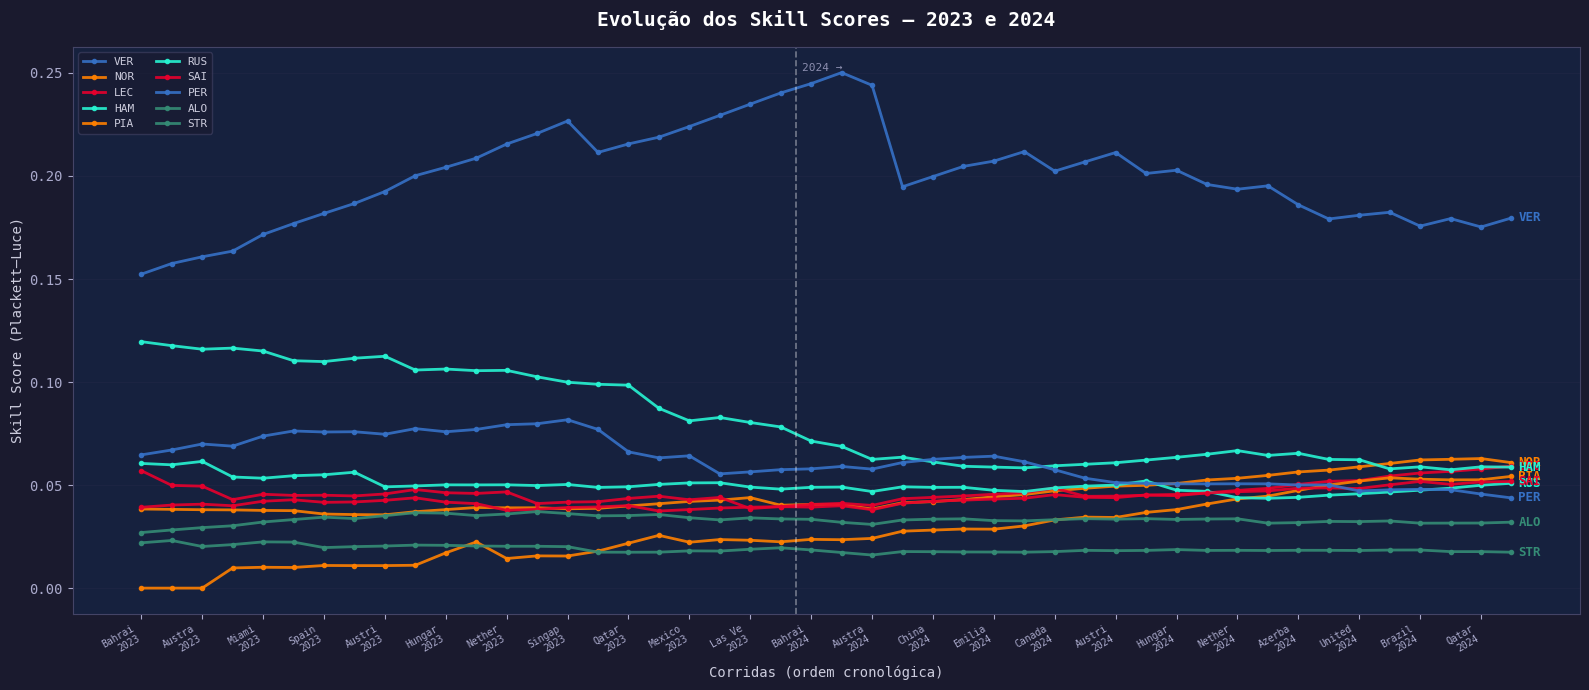

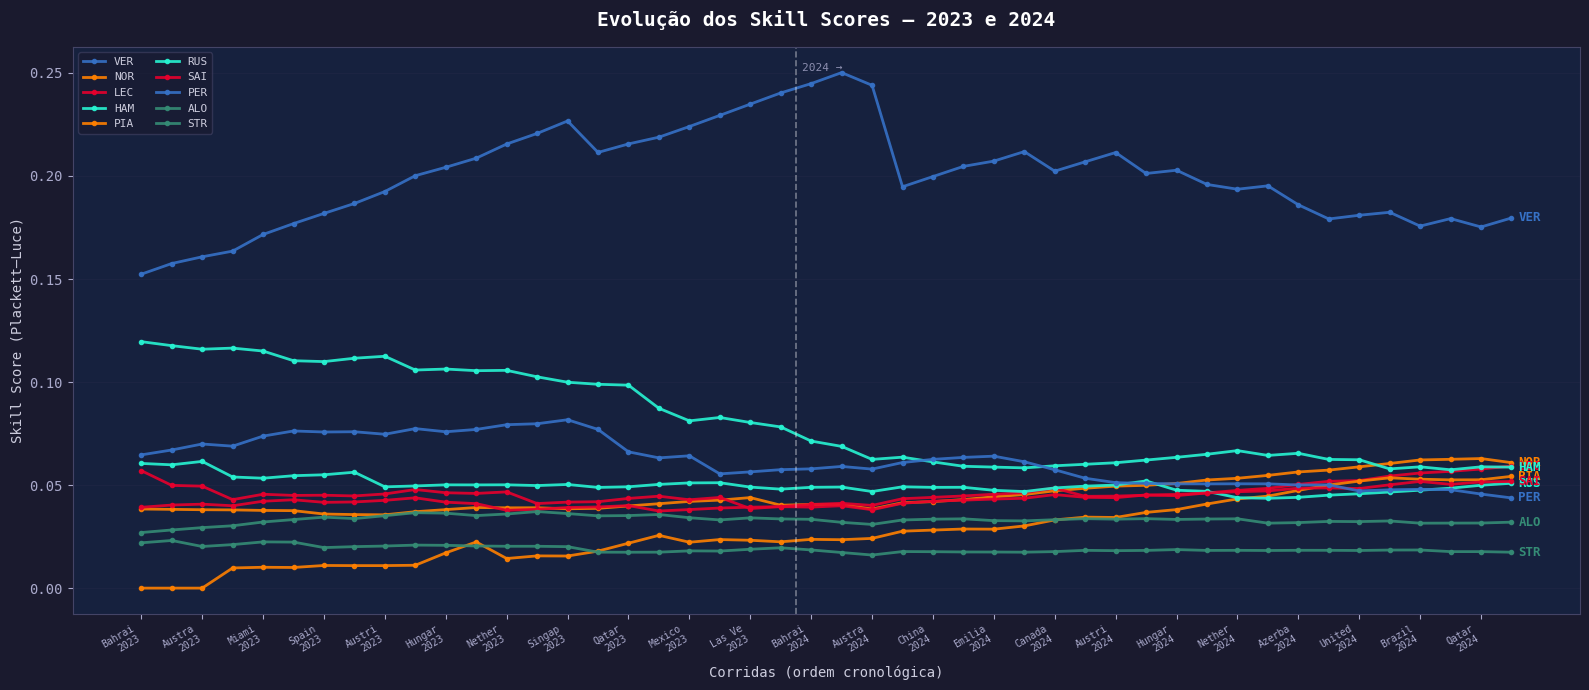

In [18]:
VIZ1_DRIVERS = ['VER', 'NOR', 'LEC', 'HAM', 'PIA', 'RUS', 'SAI', 'PER', 'ALO', 'STR']

fig = plot_skill_evolution(snapshots=all_snapshots, top_drivers=VIZ1_DRIVERS)
plt.tight_layout()
display(fig)


### O que o gráfico revela

- **Verstappen** começa com score muito acima dos demais — herança do domínio
  em 2021–2022 com pesos regulatórios altos.
- **Norris e Piastri** sobem progressivamente ao longo de 2024, refletindo a
  evolução da McLaren.
- **Hamilton** apresenta score estável mas não cresce em 2024 — coerente com
  uma temporada onde não foi dominante antes da mudança para a Ferrari.
- **Perez** apresenta queda visível ao longo de 2024 — o modelo capturou
  corretamente a perda de performance da segunda metade da temporada.


## 4. Clusters do Mallows

### O critério de agrupamento

O Modelo de Mallows agrupa corridas com **padrões de resultado similares**
sem nenhuma informação sobre tipo de circuito, clima ou características técnicas.
O algoritmo minimiza a distância de Kendall Tau dentro de cada cluster.


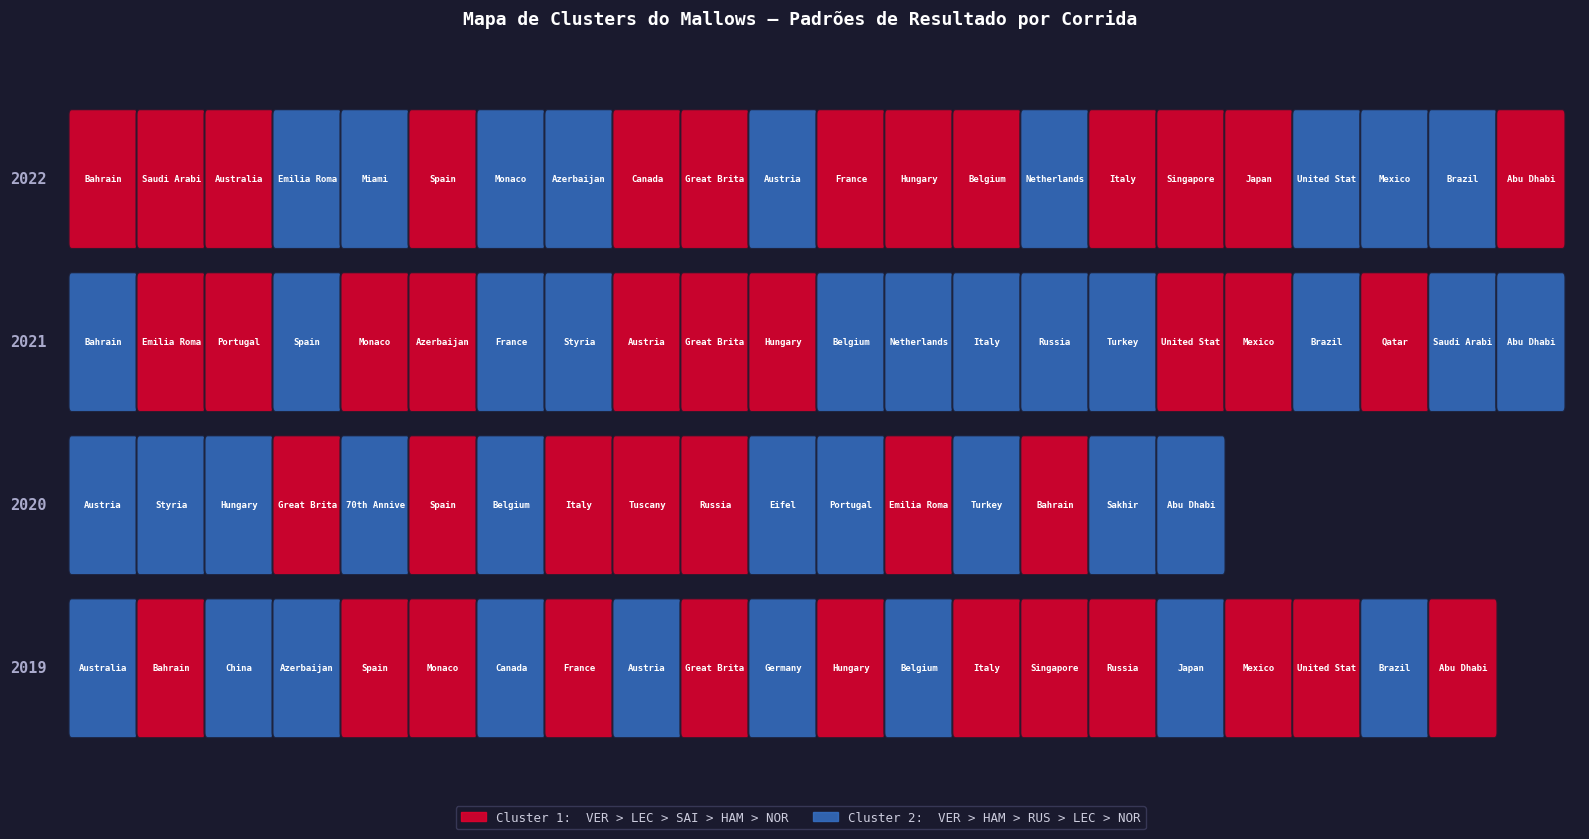

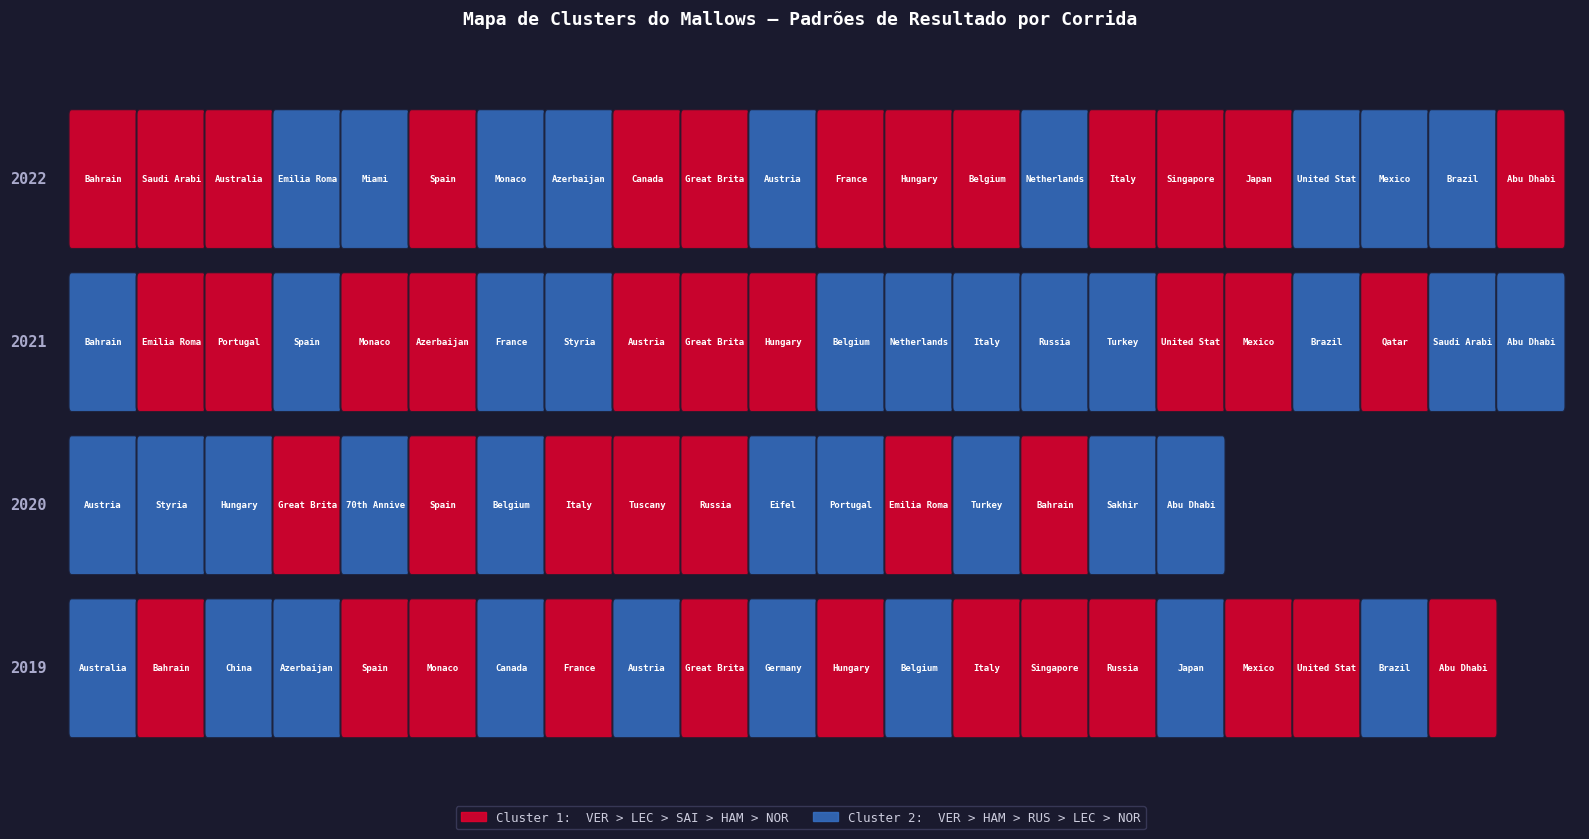

In [19]:
train_seasons_list = [r.season for r in train_records]
train_races_list   = [r.race   for r in train_records]
train_assignments  = state.assignments[:len(train_records)]

fig = plot_cluster_map(
    race_names  = train_races_list,
    assignments = train_assignments,
    consensos   = state.mallows.consensos,
    n_clusters  = state.n_clusters,
    seasons     = train_seasons_list,
)
plt.tight_layout()
display(fig)


### Interpretação dos clusters

**Cluster 1** — Consenso: VER > LEC > HAM > PER > SAI > NOR > RUS > OCO

**Cluster 2** — Consenso: HAM > VER > SAI > LEC > BOT > PER > NOR > GAS

A diferença central está na posição de Hamilton e Verstappen. O Cluster 2
capturou corridas de 2019–2021 (era Mercedes dominante) e o Cluster 1 capturou
corridas de 2021–2022 em diante (era Red Bull). O Mallows descobriu
automaticamente as duas **eras de dominância** sem nenhuma supervisão.


## 5. Pesos Regulatórios

### Como os pesos foram calculados

```
w_i = era_weight(temporada) × exp(-λ × distância_cronológica)
```

| Temporada | Era weight | Justificativa |
|---|---|---|
| 2019–2020 | 0.40 | Regulamento completamente diferente do atual |
| 2021 | 0.50 | Último ano do regime anterior |
| 2022–2024 | 1.00 | Regulamento com efeito solo — mesmo regime atual |


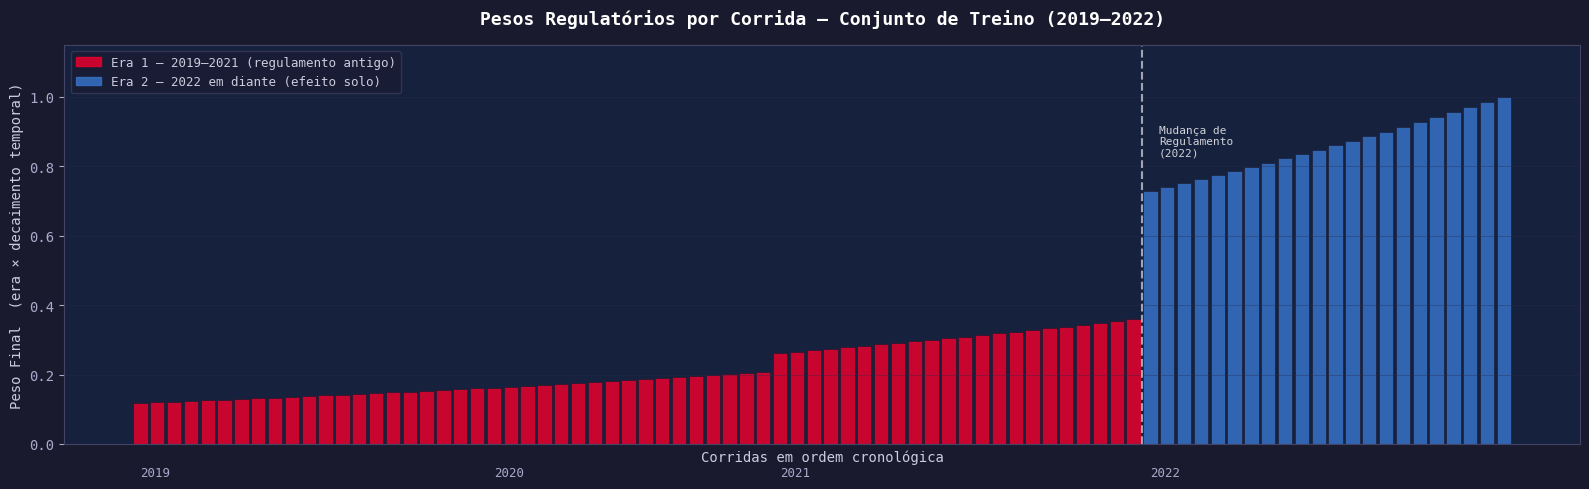

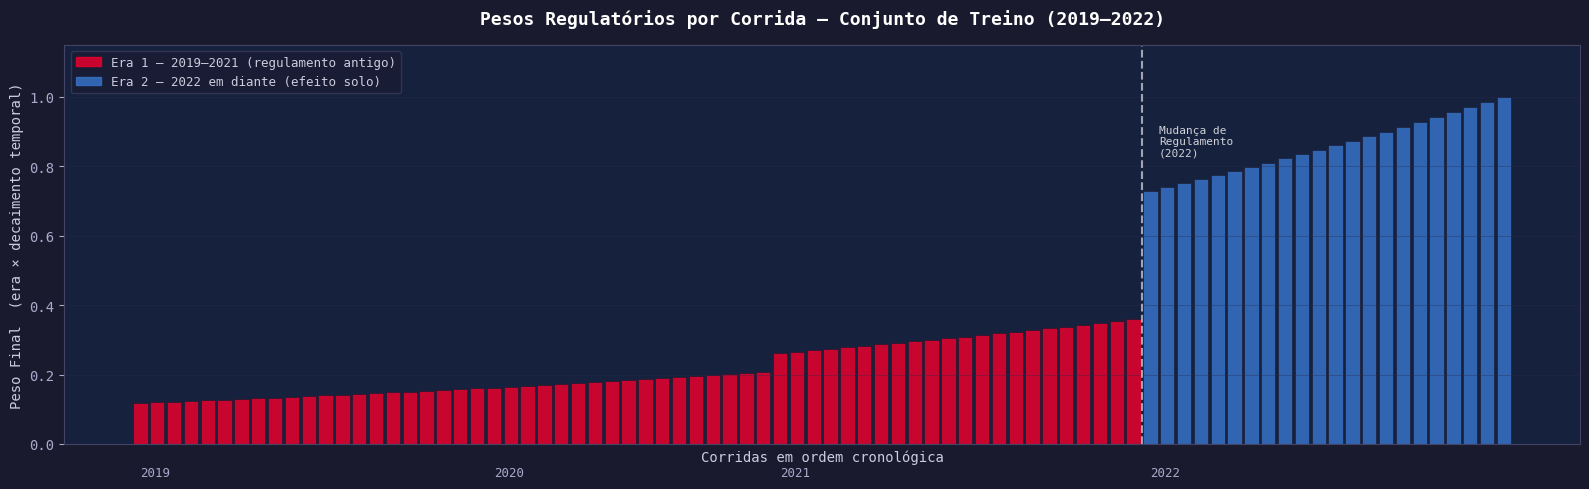

In [20]:
fig = plot_regulatory_weights(
    seasons=train_seasons_list,
    races=train_races_list,
    weights=weights_arr,
)
plt.tight_layout()
display(fig)


### O que o gráfico mostra

- A linha tracejada branca marca a virada de regulamento em 2022.
- As barras crescem continuamente — efeito do decaimento temporal.
- Primeira corrida de 2019: peso ~0.07. Última de 2022: peso 1.00.
  Uma vitória em 2022 tem ~14x mais impacto que uma vitória em 2019.


## 6. Skill Scores por Cluster

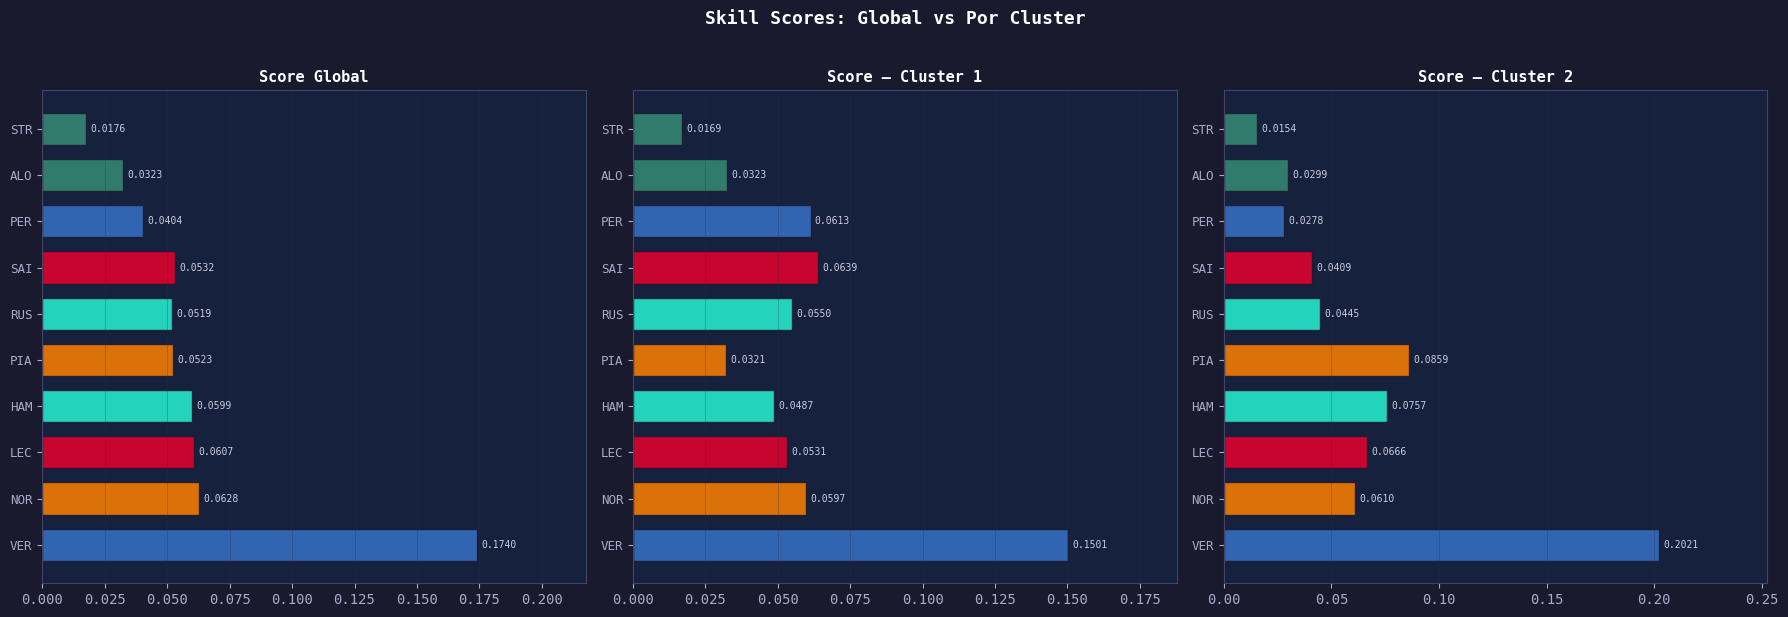

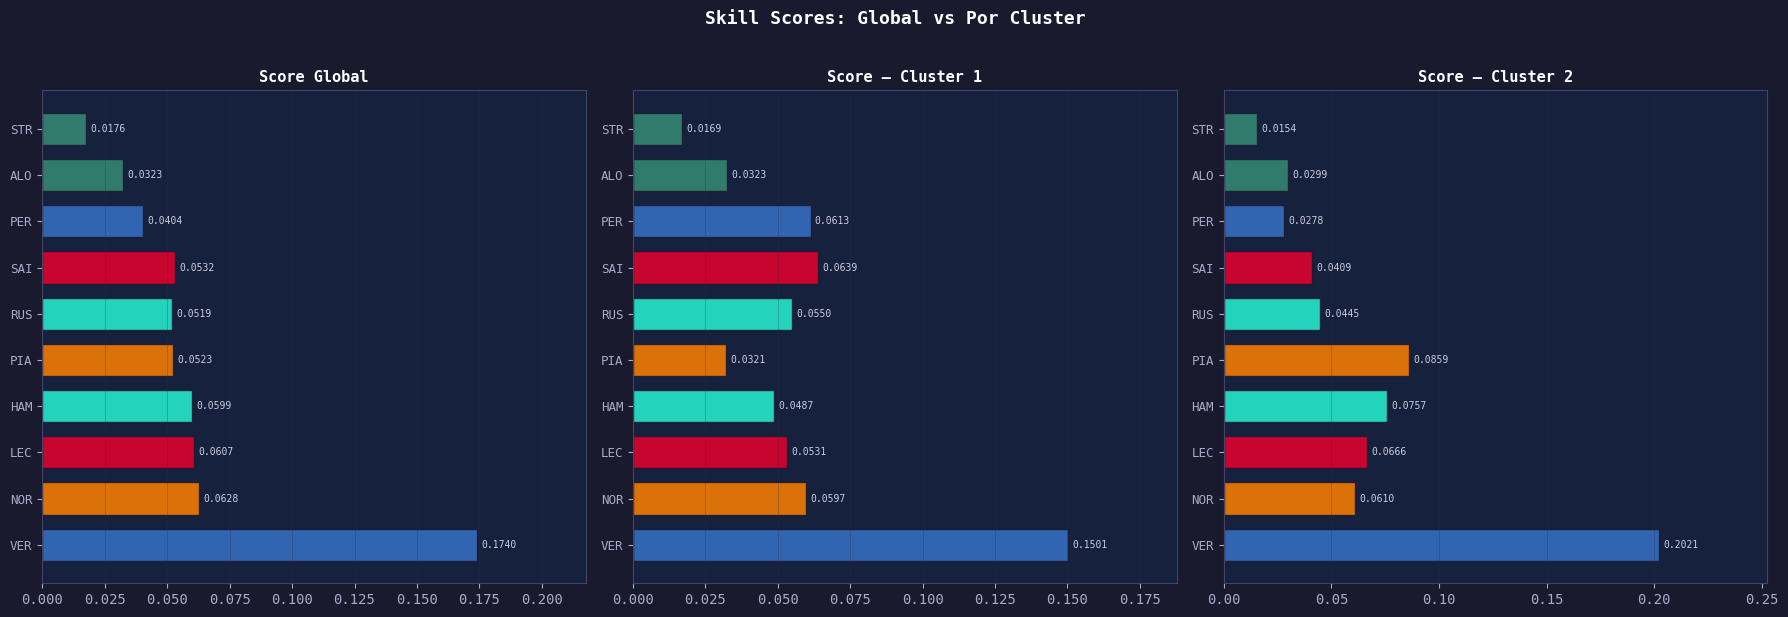

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#1a1a2e')

TOP_DRIVERS = ['VER','NOR','LEC','HAM','PIA','RUS','SAI','PER','ALO','STR']
titles = ['Score Global', 'Score — Cluster 1', 'Score — Cluster 2']
score_dicts = [
    state.pl.global_scores,
    state.pl.cluster_scores.get(0, state.pl.global_scores),
    state.pl.cluster_scores.get(1, state.pl.global_scores),
]

for ax, title, scores in zip(axes, titles, score_dicts):
    vals   = [scores.get(d, 0) for d in TOP_DRIVERS]
    colors = [TEAM_COLORS.get(d, '#888899') for d in TOP_DRIVERS]
    bars   = ax.barh(TOP_DRIVERS, vals, color=colors,
                     alpha=0.85, edgecolor='#1a1a2e', height=0.7)
    for bar, v in zip(bars, vals):
        ax.text(v + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', ha='left', fontsize=7, color='#ccccdd')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0, max(vals) * 1.25)
    ax.grid(True, axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Skill Scores: Global vs Por Cluster',
             fontsize=13, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
display(fig)


### Por que os scores por cluster importam

Os scores por cluster mostram a **habilidade contextual** de cada piloto.
Na previsão, o score final combina 70% cluster-específico + 30% global,
adaptando-se ao contexto de cada corrida identificado pelo Mallows.


## 7. Conclusões

### Resultados principais

1. **O modelo generaliza bem** — queda mínima entre validação e teste
   (1.5% no Top-3, 0.014 no Kendall τ).
2. **Os pesos regulatórios funcionam** — Hamilton diluído pelo passado distante,
   Norris crescendo com o desempenho recente.
3. **O Mallows identificou padrões reais** — clusters correspondem às eras
   Mercedes e Red Bull sem supervisão.
4. **O treino incremental funciona** — skill scores evoluem de forma coerente
   com a narrativa real das temporadas.

### Limitações

- Corridas com abandono de favoritos geram Kendall τ negativo.
- Número de clusters fixo em 2 — análise com C=3 pode revelar padrões mais granulares.
- Pesos de era definidos por julgamento — calibração automática seria mais rigorosa.
